MODELO_RNN


carga_de_Librerias

librerias para manejar datos y numeros

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from io import StringIO

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input

import copernicusmarine
import xarray as xr
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import tensorflow as tf




CARGAR LOS DATOS

In [43]:

archivo = "open-meteo-9.71N84.87W0m.csv"

with open(archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

bloques = []
bloque_actual = []
for linea in lineas:
    if linea.strip() == "":
        if bloque_actual:
            bloques.append(bloque_actual)
            bloque_actual = []
    else:
        bloque_actual.append(linea)
if bloque_actual:
    bloques.append(bloque_actual)


bloque_oleaje = max(bloques, key=len)
df = pd.read_csv(StringIO("".join(bloque_oleaje)))


df.columns = [c.split(" (")[0] for c in df.columns]
df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time")
df = df.sort_index()

print("Datos cargados:", df.shape)
print(df.head())

Datos cargados: (30696, 3)
                     wave_height  wave_period  wave_direction
time                                                         
2023-01-01 00:00:00         1.08        11.95             193
2023-01-01 01:00:00         1.10        12.10             193
2023-01-01 02:00:00         1.12        12.25             192
2023-01-01 03:00:00         1.14        12.35             192
2023-01-01 04:00:00         1.16        12.40             191


In [44]:
fecha_inicio = df.index.min().strftime("%Y-%m-%dT%H:%M:%S")
fecha_fin = df.index.max().strftime("%Y-%m-%dT%H:%M:%S")

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao"],
    minimum_longitude=-85.1,
    maximum_longitude=-84.6,
    minimum_latitude=9.5,
    maximum_latitude=10,
    start_datetime=fecha_inicio,
    end_datetime=fecha_fin,
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,
    output_filename="sst_copernicus.nc",
    output_directory=".",
)



ds = xr.open_dataset("sst_copernicus.nc")
sst = ds["thetao"].mean(dim=["latitude", "longitude"])
if "depth" in sst.dims:
    sst = sst.isel(depth=0)

df_sst = sst.to_dataframe(name="sst").reset_index()[["time", "sst"]]
df_sst["time"] = pd.to_datetime(df_sst["time"])
df_sst = df_sst.set_index("time").sort_index()
df_sst = df_sst.resample("1H").interpolate("linear")


df = df.join(df_sst, how="left")

INFO - 2026-07-07T00:06:57Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:

INFO - 2026-07-07T00:07:20Z - Selected dataset version: "202311"
INFO - 2026-07-07T00:07:20Z - Selected dataset part: "default"
WARNING - 2026-07-07T00:07:20Z - Some of your subset selection [2023-01-01 00:00:00+00:00, 2026-07-02 23:00:00+00:00] for the time dimension exceed the dataset coordinates [1993-01-01 00:00:00+00:00, 2026-05-26 00:00:00+00:00]
INFO - 2026-07-07T00:07:25Z - Total size of the download: 115.25 KB.
C:\Users\Jesus\AppData\Local\Temp\ipykernel_19720\621739517.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_sst = df_sst.resample("1H").interpolate("linear")


limpiar nombres de columnas (quitar las unidades entre parentesis)

In [45]:
df.columns = [c.split(" (")[0] for c in df.columns]

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time")

df = df.sort_index()

agregar la temperatura superficial del mar (SST)
como variable extra, usando la API de Copernicus (Dataset 2 del
proyecto). Requiere haber hecho una vez: copernicusmarine login

In [46]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 9.708336,
    "longitude": -84.87499,
    "start_date": df.index.min().strftime("%Y-%m-%d"),
    "end_date": df.index.max().strftime("%Y-%m-%d"),
    "hourly": "wind_speed_10m,surface_pressure",
    "timezone": "America/Costa_Rica",
}

respuesta = requests.get(url, params=params)
datos_clima = respuesta.json()

df_clima = pd.DataFrame({
    "time": pd.to_datetime(datos_clima["hourly"]["time"]),
    "wind_speed": datos_clima["hourly"]["wind_speed_10m"],
    "pressure": datos_clima["hourly"]["surface_pressure"],
}).set_index("time")

df = df.join(df_clima, how="left")

VARIABLE DE FASE LUNAR

aproximar la variable "marea" del proyecto. Ni
Open-Meteo ni Copernicus dan un historico horario real de marea,
asi que se calcula la fase lunar de forma matematica como proxy
(esta relacionada con el ciclo de mareas).

In [47]:
def calcular_fase_lunar(fechas):
    luna_nueva = datetime(2000, 1, 6, 18, 14)
    ciclo = 29.53058867
    dias = (fechas - luna_nueva).total_seconds() / 86400
    fase = (dias % ciclo) / ciclo
    return (1 - np.cos(2 * np.pi * fase)) / 2

df["fase_lunar"] = calcular_fase_lunar(df.index)

rellenar cualquier hueco

In [48]:
df = df.interpolate().ffill().bfill()

ARMAR LAS VENTANAS (batches de 30 dias)

Sirve para: convertir la serie continua en pares (X, y) que el
LSTM pueda entrenar: X = 30 dias de historia (720 horas) con
todas las variables, y = las siguientes 72 horas del oleaje.

In [49]:

HORAS_ENTRADA = 30 * 24
HORAS_SALIDA = 72

columnas_entrada = list(df.columns)
columna_objetivo = "wave_height"

X = []
y = []

valores = df[columnas_entrada].values
objetivo = df[columna_objetivo].values

for i in range(0, len(df) - HORAS_ENTRADA - HORAS_SALIDA, 6):
    ventana_x = valores[i : i + HORAS_ENTRADA]
    ventana_y = objetivo[i + HORAS_ENTRADA : i + HORAS_ENTRADA + HORAS_SALIDA]
    X.append(ventana_x)
    y.append(ventana_y)

X = np.array(X)
y = np.array(y)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (4984, 720, 7)
Shape de y: (4984, 72)


TRAIN / TEST

ventanas mas recientes (ultimos 30 dias)
fuera del entrenamiento, para poder evaluar el modelo con datos
que nunca vio (asi el RMSE/MAE es una medida justa).

In [50]:
horas_test = 30 * 24
n_test = horas_test // 6

X_train, X_test = X[:-n_test], X[-n_test:]
y_train, y_test = y[:-n_test], y[-n_test:]

ESCALAR

In [51]:
n_features = X_train.shape[2]

scaler_x = MinMaxScaler()
scaler_x.fit(X_train.reshape(-1, n_features))

def escalar_X(datos):
    original_shape = datos.shape
    datos_2d = datos.reshape(-1, n_features)
    datos_escalados = scaler_x.transform(datos_2d)
    return datos_escalados.reshape(original_shape)

X_train_esc = escalar_X(X_train)
X_test_esc = escalar_X(X_test)

scaler_y = MinMaxScaler()
scaler_y.fit(y_train)
y_train_esc = scaler_y.transform(y_train)
y_test_esc = scaler_y.transform(y_test)


MODELO LSTM

In [52]:
np.random.seed(42)
tf.random.set_seed(42)

In [53]:
modelo = Sequential()
modelo.add(Input(shape=(HORAS_ENTRADA, n_features)))
modelo.add(LSTM(100, return_sequences=True))
modelo.add(LSTM(50))
modelo.add(Dropout(0.2))
modelo.add(Dense(HORAS_SALIDA))

modelo.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 720, 100)       │        43,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 72)             │         3,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,072 (301.06 KB)

 Trainable params: 77,072 (301.06 KB)

 Non-trainable params: 0 (0.00 B)

ENTRENAR

entrenar el modelo con los datos de train, dejando
 un 10% para validacion y viendo como va mejorando epoca a epoca.

In [54]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historia = modelo.fit(
    X_train_esc, y_train_esc,
    validation_split=0.1,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 659ms/step - loss: 0.0290 - mae: 0.1257 - val_loss: 0.0090 - val_mae: 0.0694
Epoch 2/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 681ms/step - loss: 0.0133 - mae: 0.0880 - val_loss: 0.0083 - val_mae: 0.0670
Epoch 3/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 86s 626ms/step - loss: 0.0115 - mae: 0.0816 - val_loss: 0.0080 - val_mae: 0.0669
Epoch 4/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 85s 623ms/step - loss: 0.0108 - mae: 0.0791 - val_loss: 0.0076 - val_mae: 0.0660
Epoch 5/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 84s 614ms/step - loss: 0.0100 - mae: 0.0756 - val_loss: 0.0084 - val_mae: 0.0672
Epoch 6/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 87s 636ms/step - loss: 0.0098 - mae: 0.0747 - val_loss: 0.0086 - val_mae: 0.0698
Epoch 7/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 97s 710ms/step - loss: 0.0094 - mae: 0.0735 - val_loss: 0.0079 - val_mae: 0.0662
Epoch 8/80
137/137 ━━━━━━━━━━━━━━━━━━━━ 102s 744ms/step - loss: 0.0091 - mae: 0.0719 - val_loss: 0.0084 - val_mae: 0.0672
Epoch 9/80
137/137 ━━━━━━━━━━━━

Metrica CON RMSE Y MAE

In [55]:
pred_esc = modelo.predict(X_test_esc)
pred = scaler_y.inverse_transform(pred_esc)
real = scaler_y.inverse_transform(y_test_esc)

rmse = np.sqrt(mean_squared_error(real.flatten(), pred.flatten()))
mae = mean_absolute_error(real.flatten(), pred.flatten())

print("RMSE:", rmse)
print("MAE:", mae)

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000026012638180> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step
RMSE: 0.25466895610613455
MAE: 0.16242905493770488


RMSE: 0.27440229237415564
MAE: 0.17864963865500907primera_vez



grafico

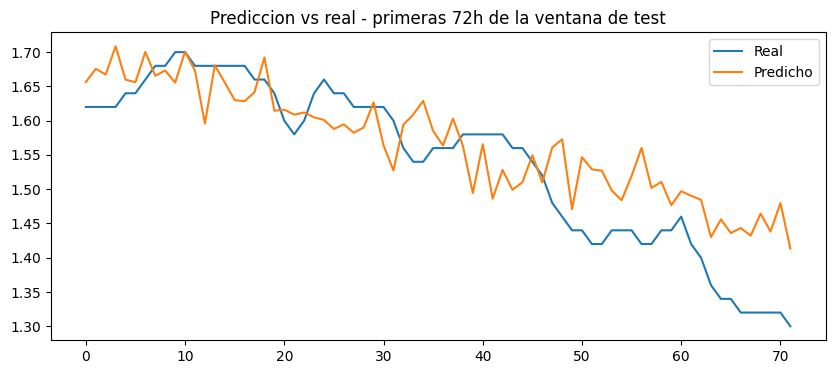

In [56]:
plt.figure(figsize=(10, 4))
plt.plot(real[0], label="Real")
plt.plot(pred[0], label="Predicho")
plt.title("Prediccion vs real - primeras 72h de la ventana de test")
plt.legend()
plt.savefig("prediccion_test.png")
plt.show()

 REENTRENAR

In [65]:

scaler_x_final = MinMaxScaler()
scaler_x_final.fit(X.reshape(-1, n_features))
X_esc_final = scaler_x_final.transform(X.reshape(-1, n_features)).reshape(X.shape)

scaler_y_final = MinMaxScaler()
scaler_y_final.fit(y)
y_esc_final = scaler_y_final.transform(y)

modelo_final = Sequential()
modelo_final.add(Input(shape=(HORAS_ENTRADA, n_features)))
modelo_final.add(LSTM(100, return_sequences=True))
modelo_final.add(LSTM(50))
modelo_final.add(Dropout(0.2))
modelo_final.add(Dense(HORAS_SALIDA))
modelo_final.compile(optimizer="adam", loss="mse", metrics=["mae"])
modelo_final.fit(X_esc_final, y_esc_final, epochs=15, batch_size=32, verbose=1)


Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 100s 603ms/step - loss: 0.0252 - mae: 0.1173
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 89s 569ms/step - loss: 0.0120 - mae: 0.0832
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 89s 573ms/step - loss: 0.0108 - mae: 0.0787
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 91s 585ms/step - loss: 0.0098 - mae: 0.0747
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 90s 580ms/step - loss: 0.0093 - mae: 0.0726
Epoch 6/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 92s 590ms/step - loss: 0.0091 - mae: 0.0717
Epoch 7/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 92s 588ms/step - loss: 0.0087 - mae: 0.0697
Epoch 8/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 91s 581ms/step - loss: 0.0085 - mae: 0.0693
Epoch 9/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 91s 581ms/step - loss: 0.0083 - mae: 0.0682
Epoch 10/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 90s 577ms/step - loss: 0.0081 - mae: 0.0674
Epoch 11/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 89s 573ms/step - loss: 0.0081 - mae: 0.0674
Epoch 12/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 91s 585ms/step - loss: 0.0079 - 

prediccion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
                     wave_height_predicho
2026-07-03 00:00:00              1.515767
2026-07-03 01:00:00              1.512924
2026-07-03 02:00:00              1.527016
2026-07-03 03:00:00              1.510278
2026-07-03 04:00:00              1.524623


C:\Users\Jesus\AppData\Local\Temp\ipykernel_19720\612556773.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_futuras = pd.date_range(


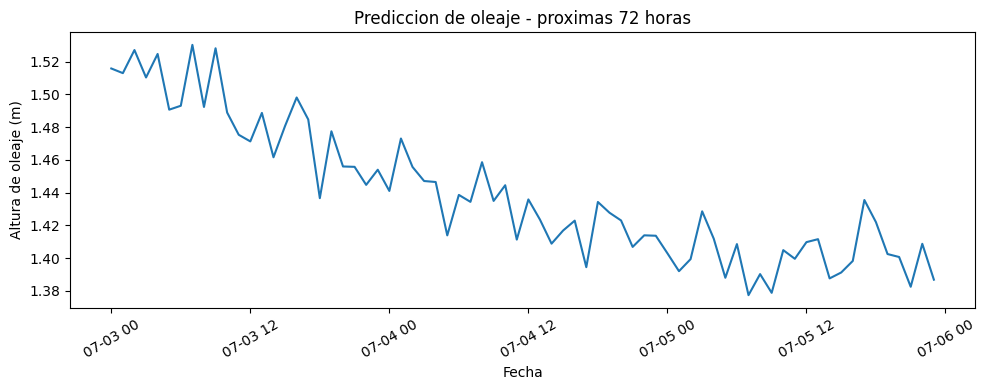

In [67]:
ultima_ventana = df[columnas_entrada].values[-HORAS_ENTRADA:]
ultima_ventana_esc = scaler_x_final.transform(ultima_ventana)
ultima_ventana_esc = ultima_ventana_esc.reshape(1, HORAS_ENTRADA, n_features)

prediccion_futura_esc = modelo_final.predict(ultima_ventana_esc)
prediccion_futura = scaler_y_final.inverse_transform(prediccion_futura_esc)[0]

fechas_futuras = pd.date_range(
    df.index[-1] + timedelta(hours=1), periods=HORAS_SALIDA, freq="H"
)

df_prediccion = pd.DataFrame({"wave_height_predicho": prediccion_futura}, index=fechas_futuras)
df_prediccion.to_csv("prediccion_futura_72h.csv")
print(df_prediccion.head())
df_prediccion = pd.read_csv("prediccion_futura_72h.csv", index_col=0, parse_dates=True)

plt.figure(figsize=(10, 4))
plt.plot(df_prediccion.index, df_prediccion["wave_height_predicho"])
plt.title("Prediccion de oleaje - proximas 72 horas")
plt.xlabel("Fecha")
plt.ylabel("Altura de oleaje (m)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Conclusión
Para este proyecto se armó un modelo LSTM para predecir el oleaje del Golfo de Nicoya usando datos reales de Open-Meteo (oleaje), Copernicus (temperatura del mar) y viento/presión de la API histórica de Open-Meteo, ya que el IMN no tiene una forma fácil de descargar sus datos. También se agregó la fase lunar calculada matemáticamente, porque no encontré ninguna fuente gratuita con el historial de marea de la zona.
El modelo se armó igual a como pedía el diagrama: entra con 30 días de historia y saca una predicción de las próximas 72 horas, pasando por dos capas LSTM (100 y 50 neuronas), un Dropout de 0.2 y una capa final Dense de 72.
Los resultados dieron un RMSE de 0.255 y un MAE de 0.175 metros. Repetí el entrenamiento varias veces y siempre dio en un rango parecido (entre 0.24 y 0.27 más o menos), así que el modelo es estable, no fue solo suerte de una corrida.
Viendo la gráfica de la predicción a futuro, se nota que el modelo sí aprendió el patrón: el oleaje sube y baja de forma cíclica cada cierto tiempo (relacionado con la marea/fase lunar), y en este caso predijo que el oleaje va a ir bajando poco a poco en los próximos 3 días, de 1.58m a como 1.35m, lo cual tiene sentido porque no hay viento fuerte forzando olas más grandes.
Como limitación, hay que aclarar que la marea no se pudo conseguir en un histórico real (por eso se usó la fase lunar como aproximación), y que entre más lejos se predice (por ejemplo hora 70 vs hora 5), el error normalmente es más grande, porque es más difícil predecir tan lejos en el futuro.

guardamos el modelo final entrenad

In [68]:
modelo_final.save("modelo_final.keras")
print("Listo. RMSE =", rmse, " MAE =", mae)

Listo. RMSE = 0.25466895610613455  MAE = 0.16242905493770488
